## load the dataset

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("/content/post natal data.csv")
df = df.drop(columns=['Timestamp'])

df['Suicide attempt'] = df['Suicide attempt'].replace('Not interested to say', np.nan)

gap_cols = ['Irritable towards baby & partner',
            'Problems concentrating or making decision',
            'Feeling of guilt']
df = df.dropna(subset=gap_cols)

ordinal_maps = {
    'Age': {'25-30': 0, '30-35': 1, '35-40': 2, '40-45': 3, '45-50': 4},
    'Feeling sad or Tearful': {'No': 0, 'Sometimes': 1, 'Yes': 2},
    'Irritable towards baby & partner': {'No': 0, 'Sometimes': 1, 'Yes': 2},
    'Trouble sleeping at night': {'No': 0, 'Two or more days a week': 1, 'Yes': 2},
    'Problems concentrating or making decision': {'No': 0, 'Often': 1, 'Yes': 2},
    'Overeating or loss of appetite': {'Not at all': 0, 'No': 1, 'Yes': 2},
    'Feeling anxious': {'No': 0, 'Yes': 1},
    'Feeling of guilt': {'No': 0, 'Maybe': 1, 'Yes': 2},
    'Problems of bonding with baby': {'No': 0, 'Sometimes': 1, 'Yes': 2},
    'Suicide attempt': {'No': 0, 'Yes': 1},
}

for col, mapping in ordinal_maps.items():
    df[col] = df[col].map(mapping)

df.to_csv('encoded_data.csv', index=False)

print('Final shape:', df.shape)
print()
print('Missing values remaining:')
print(df.isnull().sum())
print()
print(df.head(5))

Final shape: (1491, 10)

Missing values remaining:
Age                                            0
Feeling sad or Tearful                         0
Irritable towards baby & partner               0
Trouble sleeping at night                      0
Problems concentrating or making decision      0
Overeating or loss of appetite                 0
Feeling anxious                                0
Feeling of guilt                               0
Problems of bonding with baby                  0
Suicide attempt                              335
dtype: int64

   Age  Feeling sad or Tearful  Irritable towards baby & partner  \
0    2                       2                                 2   
1    3                       2                                 0   
2    2                       2                                 0   
3    2                       2                                 2   
4    3                       2                                 0   

   Trouble sleeping at night  Proble

# BASELINE 1 : kinda raw dataset

## train test split

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv('encoded_data.csv')

X = df.drop(columns=['Feeling anxious'])
y = df['Feeling anxious']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

train_df = pd.concat([X_train, y_train], axis=1)
test_df = pd.concat([X_test, y_test], axis=1)

train_df.to_csv('train_data.csv', index=False)
test_df.to_csv('test_data.csv', index=False)

print('Train shape:', train_df.shape)
print('Test shape:', test_df.shape)
print()
print('Train target balance:')
print(y_train.value_counts(normalize=True))
print()
print('Test target balance:')
print(y_test.value_counts(normalize=True))
print()
print('Train missing (Suicide attempt):', X_train['Suicide attempt'].isnull().sum())
print('Test missing (Suicide attempt):', X_test['Suicide attempt'].isnull().sum())

Train shape: (1043, 10)
Test shape: (448, 10)

Train target balance:
Feeling anxious
1    0.649089
0    0.350911
Name: proportion, dtype: float64

Test target balance:
Feeling anxious
1    0.649554
0    0.350446
Name: proportion, dtype: float64

Train missing (Suicide attempt): 227
Test missing (Suicide attempt): 108


In [ ]:
pip install pgmpy

## all 7 models applied

In [ ]:
import warnings
warnings.filterwarnings('ignore')

from pgmpy.estimators import TreeSearch, HillClimbSearch, PC, BIC
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.parameter_estimator import DiscreteMLE
from pgmpy.inference import VariableElimination
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score

target_col = 'Feeling anxious'
train_df = pd.read_csv('train_data.csv')
test_df = pd.read_csv('test_data.csv')
feature_cols = [c for c in train_df.columns if c != target_col]

results = []


def evaluate_pgm(model, test_df, feature_cols):
    infer = VariableElimination(model)
    test_complete = test_df.dropna()
    preds = []
    for _, row in test_complete.iterrows():
        evidence = {col: int(row[col]) for col in feature_cols if col in model.nodes()}
        result = infer.map_query(variables=[target_col], evidence=evidence, show_progress=False)
        preds.append(result[target_col])
    y_true = test_complete[target_col]
    return accuracy_score(y_true, preds), f1_score(y_true, preds), len(y_true)


train_complete = train_df.dropna()

est = TreeSearch(train_complete, root_node='Age')
dag = est.estimate(estimator_type='chow-liu', show_progress=False)
model = DiscreteBayesianNetwork(dag.edges())
model.fit(train_complete, estimator=DiscreteMLE())
acc, f1, n = evaluate_pgm(model, test_df, feature_cols)
results.append({'model': 'Tree Search', 'accuracy': acc, 'f1_score': f1, 'n_test': n, 'edges': len(dag.edges())})
print(f'Tree Search          | acc={acc:.4f} | f1={f1:.4f} | n={n}')

scoring = BIC(train_complete)
hc = HillClimbSearch(train_complete)
dag = hc.estimate(scoring_method=scoring, show_progress=False)
model = DiscreteBayesianNetwork(dag.edges())
model.fit(train_complete, estimator=DiscreteMLE())
acc, f1, n = evaluate_pgm(model, test_df, feature_cols)
results.append({'model': 'Hill Climb Search', 'accuracy': acc, 'f1_score': f1, 'n_test': n, 'edges': len(dag.edges())})
print(f'Hill Climb Search    | acc={acc:.4f} | f1={f1:.4f} | n={n}')

pc = PC(train_complete)
dag = pc.estimate(variant='stable', ci_test='chi_square', return_type='dag',
                   significance_level=0.05, max_cond_vars=3, n_jobs=1, show_progress=False)
model = DiscreteBayesianNetwork(dag.edges())
model.fit(train_complete, estimator=DiscreteMLE())
acc, f1, n = evaluate_pgm(model, test_df, feature_cols)
results.append({'model': 'PC Algorithm', 'accuracy': acc, 'f1_score': f1, 'n_test': n, 'edges': len(dag.edges())})
print(f'PC Algorithm          | acc={acc:.4f} | f1={f1:.4f} | n={n}')

edges_nb = [(target_col, f) for f in feature_cols]
model = DiscreteBayesianNetwork(edges_nb)
model.fit(train_complete, estimator=DiscreteMLE())
acc, f1, n = evaluate_pgm(model, test_df, feature_cols)
results.append({'model': 'Naive Bayes', 'accuracy': acc, 'f1_score': f1, 'n_test': n, 'edges': len(edges_nb)})
print(f'Naive Bayes           | acc={acc:.4f} | f1={f1:.4f} | n={n}')

mode_value = train_df['Suicide attempt'].mode()[0]
train_imp = train_df.copy()
test_imp = test_df.copy()
train_imp['Suicide attempt'] = train_imp['Suicide attempt'].fillna(mode_value)
test_imp['Suicide attempt'] = test_imp['Suicide attempt'].fillna(mode_value)

X_train, y_train = train_imp[feature_cols], train_imp[target_col]
X_test, y_test = test_imp[feature_cols], test_imp[target_col]

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)
preds = model.predict(X_test)
acc, f1 = accuracy_score(y_test, preds), f1_score(y_test, preds)
results.append({'model': 'Logistic Regression', 'accuracy': acc, 'f1_score': f1, 'n_test': len(y_test), 'edges': None})
print(f'Logistic Regression   | acc={acc:.4f} | f1={f1:.4f} | n={len(y_test)}')

model = RandomForestClassifier(n_estimators=200, max_depth=5, min_samples_leaf=5, random_state=42)
model.fit(X_train, y_train)
preds = model.predict(X_test)
acc, f1 = accuracy_score(y_test, preds), f1_score(y_test, preds)
results.append({'model': 'Random Forest', 'accuracy': acc, 'f1_score': f1, 'n_test': len(y_test), 'edges': None})
print(f'Random Forest          | acc={acc:.4f} | f1={f1:.4f} | n={len(y_test)}')

model = XGBClassifier(n_estimators=150, max_depth=3, min_child_weight=15,
                       reg_lambda=2.0, eval_metric='logloss', random_state=42)
model.fit(train_df[feature_cols], train_df[target_col])
preds = model.predict(test_df[feature_cols])
acc, f1 = accuracy_score(test_df[target_col], preds), f1_score(test_df[target_col], preds)
results.append({'model': 'XGBoost', 'accuracy': acc, 'f1_score': f1, 'n_test': len(test_df), 'edges': None})
print(f'XGBoost                | acc={acc:.4f} | f1={f1:.4f} | n={len(test_df)}')

results_df = pd.DataFrame(results)
results_df.to_csv('baseline1_results.csv', index=False)
print()
print('Saved to baseline1_results.csv')

Tree Search          | acc=0.7735 | f1=0.8544 | n=340
Hill Climb Search    | acc=0.8529 | f1=0.8963 | n=340
PC Algorithm          | acc=0.9588 | f1=0.9721 | n=340
Naive Bayes           | acc=0.8000 | f1=0.8656 | n=340
Logistic Regression   | acc=0.8304 | f1=0.8703 | n=448
Random Forest          | acc=0.8683 | f1=0.9002 | n=448
XGBoost                | acc=0.8884 | f1=0.9147 | n=448

Saved to baseline1_results.csv


# BASELINE 2 : cleaned dataset

## train test split

In [ ]:
df = pd.read_csv('/content/encoded_data.csv')
df_complete = df.dropna()

print('Fully complete rows:', len(df_complete))

X = df_complete.drop(columns=['Feeling anxious'])
y = df_complete['Feeling anxious']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

train_df = pd.concat([X_train, y_train], axis=1)
test_df = pd.concat([X_test, y_test], axis=1)

train_df.to_csv('train_data_complete.csv', index=False)
test_df.to_csv('test_data_complete.csv', index=False)

print('Train shape:', train_df.shape)
print('Test shape:', test_df.shape)
print()
print('Train target balance:')
print(y_train.value_counts(normalize=True))
print('\n Test target balance:')
print(y_test.value_counts(normalize=True))

Fully complete rows: 1156
Train shape: (809, 10)
Test shape: (347, 10)

Train target balance:
Feeling anxious
1    0.724351
0    0.275649
Name: proportion, dtype: float64

 Test target balance:
Feeling anxious
1    0.726225
0    0.273775
Name: proportion, dtype: float64


## all 7 models applied

In [ ]:
train_df = pd.read_csv('train_data_complete.csv')
test_df = pd.read_csv('test_data_complete.csv')

target_col = 'Feeling anxious'
feature_cols = [c for c in train_df.columns if c != target_col]

results = []


def evaluate_pgm(model, test_df, feature_cols):
    infer = VariableElimination(model)
    preds = []
    for _, row in test_df.iterrows():
        evidence = {col: int(row[col]) for col in feature_cols if col in model.nodes()}
        result = infer.map_query(variables=[target_col], evidence=evidence, show_progress=False)
        preds.append(result[target_col])
    y_true = test_df[target_col]
    return accuracy_score(y_true, preds), f1_score(y_true, preds), len(y_true)


est = TreeSearch(train_df, root_node='Age')
dag = est.estimate(estimator_type='chow-liu', show_progress=False)
model = DiscreteBayesianNetwork(dag.edges())
model.fit(train_df, estimator=DiscreteMLE())
acc, f1, n = evaluate_pgm(model, test_df, feature_cols)
results.append({'model': 'Tree Search', 'accuracy': acc, 'f1_score': f1, 'n_test': n, 'edges': len(dag.edges())})
print(f'Tree Search       | acc={acc:.4f} | f1={f1:.4f} | edges={len(dag.edges())}')

scoring = BIC(train_df)
hc = HillClimbSearch(train_df)
dag = hc.estimate(scoring_method=scoring, show_progress=False)
model = DiscreteBayesianNetwork(dag.edges())
model.fit(train_df, estimator=DiscreteMLE())
acc, f1, n = evaluate_pgm(model, test_df, feature_cols)
results.append({'model': 'Hill Climb Search', 'accuracy': acc, 'f1_score': f1, 'n_test': n, 'edges': len(dag.edges())})
print(f'Hill Climb Search | acc={acc:.4f} | f1={f1:.4f} | edges={len(dag.edges())}')

pc = PC(train_df)
dag = pc.estimate(variant='stable', ci_test='chi_square', return_type='dag',
                   significance_level=0.05, max_cond_vars=3, n_jobs=1, show_progress=False)
model = DiscreteBayesianNetwork(dag.edges())
model.fit(train_df, estimator=DiscreteMLE())
acc, f1, n = evaluate_pgm(model, test_df, feature_cols)
results.append({'model': 'PC Algorithm', 'accuracy': acc, 'f1_score': f1, 'n_test': n, 'edges': len(dag.edges())})
print(f'PC Algorithm      | acc={acc:.4f} | f1={f1:.4f} | edges={len(dag.edges())}')

edges = [(target_col, f) for f in feature_cols]
model = DiscreteBayesianNetwork(edges)
model.fit(train_df, estimator=DiscreteMLE())
acc, f1, n = evaluate_pgm(model, test_df, feature_cols)
results.append({'model': 'Naive Bayes', 'accuracy': acc, 'f1_score': f1, 'n_test': n, 'edges': len(edges)})
print(f'Naive Bayes       | acc={acc:.4f} | f1={f1:.4f} | edges={len(edges)}')

X_train, y_train = train_df[feature_cols], train_df[target_col]
X_test, y_test = test_df[feature_cols], test_df[target_col]

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)
preds = model.predict(X_test)
acc, f1 = accuracy_score(y_test, preds), f1_score(y_test, preds)
results.append({'model': 'Logistic Regression', 'accuracy': acc, 'f1_score': f1, 'n_test': len(y_test), 'edges': None})
print(f'Logistic Regression | acc={acc:.4f} | f1={f1:.4f}')

model = RandomForestClassifier(n_estimators=200, max_depth=5, min_samples_leaf=5, random_state=42)
model.fit(X_train, y_train)
preds = model.predict(X_test)
acc, f1 = accuracy_score(y_test, preds), f1_score(y_test, preds)
results.append({'model': 'Random Forest', 'accuracy': acc, 'f1_score': f1, 'n_test': len(y_test), 'edges': None})
print(f'Random Forest     | acc={acc:.4f} | f1={f1:.4f}')

model = XGBClassifier(n_estimators=150, max_depth=3, min_child_weight=15,
                       reg_lambda=2.0, eval_metric='logloss', random_state=42)
model.fit(X_train, y_train)
preds = model.predict(X_test)
acc, f1 = accuracy_score(y_test, preds), f1_score(y_test, preds)
results.append({'model': 'XGBoost', 'accuracy': acc, 'f1_score': f1, 'n_test': len(y_test), 'edges': None})
print(f'XGBoost           | acc={acc:.4f} | f1={f1:.4f}')

results_df = pd.DataFrame(results)
results_df.to_csv('baseline2_results.csv', index=False)
print()
print('Saved to baseline2_results.csv')

Tree Search       | acc=0.8040 | f1=0.8750 | edges=9
Hill Climb Search | acc=0.8703 | f1=0.9136 | edges=20
PC Algorithm      | acc=0.9712 | f1=0.9798 | edges=40
Naive Bayes       | acc=0.8357 | f1=0.8914 | edges=9
Logistic Regression | acc=0.8098 | f1=0.8782
Random Forest     | acc=0.9193 | f1=0.9457
XGBoost           | acc=0.8991 | f1=0.9331

Saved to baseline2_results.csv


# baseline comparison chart

In [ ]:
import pandas as pd

b1 = pd.read_csv('baseline1_results.csv')[['model', 'accuracy']].rename(columns={'accuracy': 'baseline1'})
b2 = pd.read_csv('complete_baseline_results.csv')[['model', 'accuracy']].rename(columns={'accuracy': 'baseline2'})

merged = b1.merge(b2, on='model')
merged.to_csv('baseline_comparison.csv', index=False)
print(merged)

                 model  baseline1  baseline2
0          Tree Search   0.773529   0.804035
1    Hill Climb Search   0.852941   0.870317
2         PC Algorithm   0.958824   0.971182
3          Naive Bayes   0.800000   0.835735
4  Logistic Regression   0.830357   0.809798
5        Random Forest   0.868304   0.919308
6              XGBoost   0.888393   0.899135


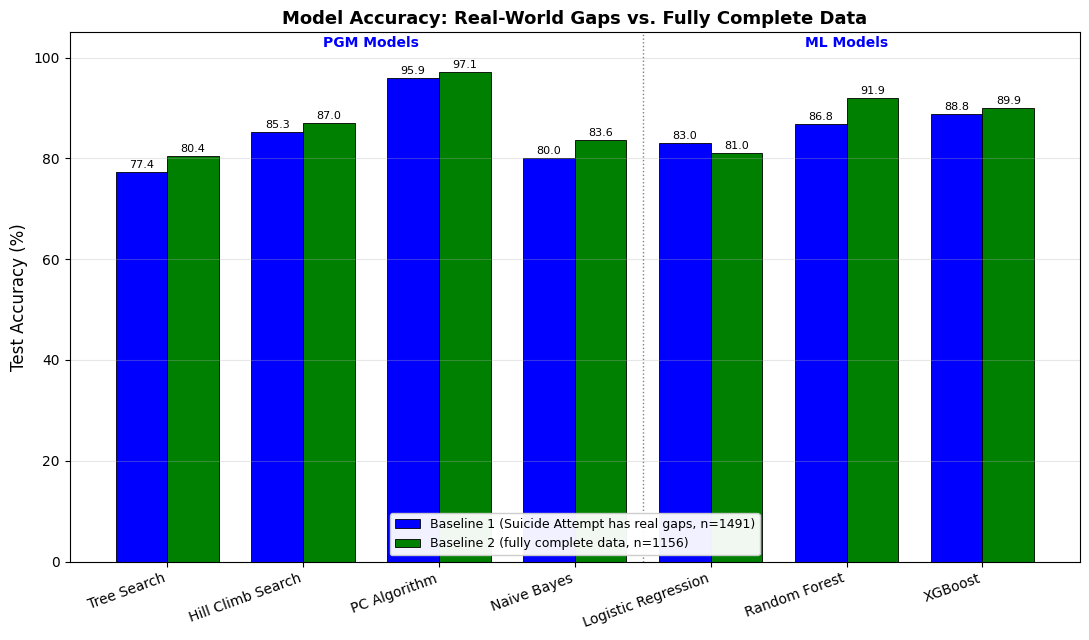

Saved: chart1_baseline_comparison.png


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('baseline_comparison.csv')

pgm_models = ['Tree Search', 'Hill Climb Search', 'PC Algorithm', 'Naive Bayes']
df['type'] = df['model'].apply(lambda m: 'PGM' if m in pgm_models else 'ML')

x = np.arange(len(df))
width = 0.38

fig, ax = plt.subplots(figsize=(11, 6.5))

bars1 = ax.bar(x - width/2, df['baseline1'] * 100, width,
                label='Baseline 1 (Suicide Attempt has real gaps, n=1491)',
                color='blue', edgecolor='black', linewidth=0.6)
bars2 = ax.bar(x + width/2, df['baseline2'] * 100, width,
                label='Baseline 2 (fully complete data, n=1156)',
                color='green', edgecolor='black', linewidth=0.6)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.1f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords='offset points',
                    ha='center', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(df['model'], rotation=20, ha='right', fontsize=10)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('Model Accuracy: Real-World Gaps vs. Fully Complete Data', fontsize=13, fontweight='bold')
ax.set_ylim(0, 105)
ax.axvline(x=3.5, color='gray', linestyle=':', linewidth=1)
ax.text(1.5, 102, 'PGM Models', ha='center', fontsize=10, fontweight='bold', color='blue')
ax.text(5, 102, 'ML Models', ha='center', fontsize=10, fontweight='bold', color='blue')
ax.legend(loc='lower center', fontsize=9, framealpha=0.95)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('chart1_baseline_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print('Saved: chart1_baseline_comparison.png')

# training and testing

## trained and tested on baseline 1 data

In [ ]:
train_df = pd.read_csv('train_data.csv')
test_df_clean = pd.read_csv('test_data.csv')
feature_cols = [c for c in train_df.columns if c != target_col]

train_complete = train_df.dropna()
print('Training rows used for PGM structure learning (Baseline 1, complete-only):', len(train_complete))

est = TreeSearch(train_complete, root_node='Age')
dag_tree = est.estimate(estimator_type='chow-liu', show_progress=False)
model_tree = DiscreteBayesianNetwork(dag_tree.edges())
model_tree.fit(train_complete, estimator=DiscreteMLE())

scoring = BIC(train_complete)
hc = HillClimbSearch(train_complete)
dag_hc = hc.estimate(scoring_method=scoring, show_progress=False)
model_hc = DiscreteBayesianNetwork(dag_hc.edges())
model_hc.fit(train_complete, estimator=DiscreteMLE())

pc = PC(train_complete)
dag_pc = pc.estimate(variant='stable', ci_test='chi_square', return_type='dag',
                      significance_level=0.05, max_cond_vars=3, n_jobs=1, show_progress=False)
model_pc = DiscreteBayesianNetwork(dag_pc.edges())
model_pc.fit(train_complete, estimator=DiscreteMLE())

edges_nb = [(target_col, f) for f in feature_cols]
model_nb = DiscreteBayesianNetwork(edges_nb)
model_nb.fit(train_complete, estimator=DiscreteMLE())

X_train_imp = train_df[feature_cols].copy()
mode_values = X_train_imp.mode().iloc[0]
X_train_imp = X_train_imp.fillna(mode_values)
y_train = train_df[target_col]

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_imp, y_train)

rf = RandomForestClassifier(n_estimators=200, max_depth=5, min_samples_leaf=5, random_state=42)
rf.fit(X_train_imp, y_train)

xgb = XGBClassifier(n_estimators=150, max_depth=3, min_child_weight=15,
                     reg_lambda=2.0, eval_metric='logloss', random_state=42)
xgb.fit(train_df[feature_cols], y_train)

print('All 7 models trained once on Baseline 1 data.')
print()

fixed_pgm_models = {
    'Tree Search': model_tree,
    'Hill Climb Search': model_hc,
    'PC Algorithm': model_pc,
    'Naive Bayes': model_nb,
}


def evaluate_pgm_partial(model, test_df, feature_cols):
    infer = VariableElimination(model)
    preds = []
    for _, row in test_df.iterrows():
        evidence = {
            col: int(row[col]) for col in feature_cols
            if col in model.nodes() and not pd.isna(row[col])
        }
        try:
            result = infer.map_query(variables=[target_col], evidence=evidence, show_progress=False)
            preds.append(result[target_col])
        except Exception:
            preds.append(np.nan)
    valid = ~pd.isna(preds)
    y_true = test_df[target_col][valid]
    y_pred = pd.Series(preds)[valid].astype(int)
    if len(y_true) == 0:
        return np.nan, np.nan, 0
    return accuracy_score(y_true, y_pred), f1_score(y_true, y_pred), len(y_true)


def add_mcar_missing(df, cols, fraction, seed):
    df_out = df.copy()
    rng = np.random.RandomState(seed)
    for col in cols:
        n_missing = int(round(len(df_out) * fraction))
        idx = rng.choice(df_out.index, size=n_missing, replace=False)
        df_out.loc[idx, col] = np.nan
    return df_out


results = []

for pct in [0, 10, 20, 30, 40]:
    if pct == 0:
        test_corrupted = test_df_clean.copy()
    else:
        test_corrupted = add_mcar_missing(test_df_clean, feature_cols, pct / 100, seed=400 + pct)

    y_test = test_corrupted[target_col]

    for model_name, model in fixed_pgm_models.items():
        acc, f1, n = evaluate_pgm_partial(model, test_corrupted, feature_cols)
        results.append({'missing_pct': pct, 'model': model_name, 'accuracy': acc, 'f1_score': f1, 'n_test': n})
        print(f'missing={pct}% | {model_name:20s} | acc={acc:.4f} | f1={f1:.4f} | n={n}')

    X_test_imp = test_corrupted[feature_cols].fillna(mode_values)
    preds_lr = log_reg.predict(X_test_imp)
    preds_rf = rf.predict(X_test_imp)
    preds_xgb = xgb.predict(test_corrupted[feature_cols])

    for name, preds in [('Logistic Regression', preds_lr), ('Random Forest', preds_rf), ('XGBoost', preds_xgb)]:
        acc = accuracy_score(y_test, preds)
        f1 = f1_score(y_test, preds)
        results.append({'missing_pct': pct, 'model': name, 'accuracy': acc, 'f1_score': f1, 'n_test': len(y_test)})
        print(f'missing={pct}% | {name:20s} | acc={acc:.4f} | f1={f1:.4f} | n={len(y_test)}')

results_df = pd.DataFrame(results)
results_df.to_csv('experiment_A_baseline1_results.csv', index=False)
print()
print('Saved to experiment_A_baseline1_results.csv')

Training rows used for PGM structure learning (Baseline 1, complete-only): 816


All 7 models trained once on Baseline 1 data.

missing=0% | Tree Search          | acc=0.7634 | f1=0.8317 | n=448
missing=0% | Hill Climb Search    | acc=0.8147 | f1=0.8571 | n=448
missing=0% | PC Algorithm         | acc=0.8616 | f1=0.8949 | n=448
missing=0% | Naive Bayes          | acc=0.7879 | f1=0.8425 | n=448
missing=0% | Logistic Regression  | acc=0.8304 | f1=0.8703 | n=448
missing=0% | Random Forest        | acc=0.8683 | f1=0.9002 | n=448
missing=0% | XGBoost              | acc=0.8884 | f1=0.9147 | n=448
missing=10% | Tree Search          | acc=0.7478 | f1=0.8243 | n=448
missing=10% | Hill Climb Search    | acc=0.7902 | f1=0.8379 | n=448
missing=10% | PC Algorithm         | acc=0.8527 | f1=0.8900 | n=448
missing=10% | Naive Bayes          | acc=0.7969 | f1=0.8496 | n=448
missing=10% | Logistic Regression  | acc=0.8058 | f1=0.8548 | n=448
missing=10% | Random Forest        | acc=0.8326 | f1=0.8760 | n=448
missing=10% | XGBoost              | acc=0.8683 | f1=0.8970 | n=448
missing=

## trained and tested on baseline 2 data

In [ ]:
target_col = 'Feeling anxious'

train_df = pd.read_csv('train_data_complete.csv')
feature_cols = [c for c in train_df.columns if c != target_col]

print('Learning all 4 PGM structures once, on complete training data...')

est = TreeSearch(train_df, root_node='Age')
dag_tree = est.estimate(estimator_type='chow-liu', show_progress=False)
model_tree = DiscreteBayesianNetwork(dag_tree.edges())
model_tree.fit(train_df, estimator=DiscreteMLE())

scoring = BIC(train_df)
hc = HillClimbSearch(train_df)
dag_hc = hc.estimate(scoring_method=scoring, show_progress=False)
model_hc = DiscreteBayesianNetwork(dag_hc.edges())
model_hc.fit(train_df, estimator=DiscreteMLE())

pc = PC(train_df)
dag_pc = pc.estimate(variant='stable', ci_test='chi_square', return_type='dag',
                      significance_level=0.05, max_cond_vars=3, n_jobs=1, show_progress=False)
model_pc = DiscreteBayesianNetwork(dag_pc.edges())
model_pc.fit(train_df, estimator=DiscreteMLE())

edges_nb = [(target_col, f) for f in feature_cols]
model_nb = DiscreteBayesianNetwork(edges_nb)
model_nb.fit(train_df, estimator=DiscreteMLE())

print('All 4 structures learned. Now testing on increasingly corrupted test sets.')
print()

fixed_models = {
    'Tree Search': model_tree,
    'Hill Climb Search': model_hc,
    'PC Algorithm': model_pc,
    'Naive Bayes': model_nb,
}


def evaluate_pgm_partial(model, test_df, feature_cols):
    infer = VariableElimination(model)
    preds = []
    for _, row in test_df.iterrows():
        evidence = {
            col: int(row[col]) for col in feature_cols
            if col in model.nodes() and not pd.isna(row[col])
        }
        try:
            result = infer.map_query(variables=[target_col], evidence=evidence, show_progress=False)
            preds.append(result[target_col])
        except Exception:
            preds.append(np.nan)
    valid = ~pd.isna(preds)
    y_true = test_df[target_col][valid]
    y_pred = pd.Series(preds)[valid].astype(int)
    if len(y_true) == 0:
        return np.nan, np.nan, 0
    return accuracy_score(y_true, y_pred), f1_score(y_true, y_pred), len(y_true)


def add_mcar_missing(df, cols, fraction, seed):
    df_out = df.copy()
    rng = np.random.RandomState(seed)
    for col in cols:
        n_missing = int(round(len(df_out) * fraction))
        idx = rng.choice(df_out.index, size=n_missing, replace=False)
        df_out.loc[idx, col] = np.nan
    return df_out


test_df_clean = pd.read_csv('test_data_complete.csv')
results = []

for pct in [0, 10, 20, 30, 40]:
    if pct == 0:
        test_corrupted = test_df_clean.copy()
    else:
        test_corrupted = add_mcar_missing(test_df_clean, feature_cols, pct / 100, seed=300 + pct)

    for model_name, model in fixed_models.items():
        acc, f1, n = evaluate_pgm_partial(model, test_corrupted, feature_cols)
        results.append({'missing_pct': pct, 'model': model_name, 'accuracy': acc, 'f1_score': f1, 'n_test': n})
        print(f'missing={pct}% | {model_name:18s} | acc={acc:.4f} | f1={f1:.4f} | n={n}')

results_df = pd.DataFrame(results)
results_df.to_csv('experiment_A_pgm_results.csv', index=False)
print()
print('Saved to experiment_A_pgm_results.csv')

Learning all 4 PGM structures once, on complete training data...


All 4 structures learned. Now testing on increasingly corrupted test sets.

missing=0% | Tree Search        | acc=0.8040 | f1=0.8750 | n=347
missing=0% | Hill Climb Search  | acc=0.8703 | f1=0.9136 | n=347
missing=0% | PC Algorithm       | acc=0.9712 | f1=0.9798 | n=347
missing=0% | Naive Bayes        | acc=0.8357 | f1=0.8914 | n=347
missing=10% | Tree Search        | acc=0.7954 | f1=0.8702 | n=347
missing=10% | Hill Climb Search  | acc=0.8559 | f1=0.9031 | n=347
missing=10% | PC Algorithm       | acc=0.9769 | f1=0.9840 | n=347
missing=10% | Naive Bayes        | acc=0.8329 | f1=0.8893 | n=347
missing=20% | Tree Search        | acc=0.7723 | f1=0.8592 | n=347
missing=20% | Hill Climb Search  | acc=0.8386 | f1=0.8931 | n=347
missing=20% | PC Algorithm       | acc=0.9625 | f1=0.9743 | n=347
missing=20% | Naive Bayes        | acc=0.8501 | f1=0.9015 | n=347
missing=30% | Tree Search        | acc=0.7723 | f1=0.8582 | n=347
missing=30% | Hill Climb Search  | acc=0.8386 | f1=0.8923 | n=347
miss

In [ ]:
target_col = 'Feeling anxious'

train_df = pd.read_csv('train_data_complete.csv')
test_df_clean = pd.read_csv('test_data_complete.csv')
feature_cols = [c for c in train_df.columns if c != target_col]

X_train, y_train = train_df[feature_cols], train_df[target_col]

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

rf = RandomForestClassifier(n_estimators=200, max_depth=5, min_samples_leaf=5, random_state=42)
rf.fit(X_train, y_train)

xgb = XGBClassifier(n_estimators=150, max_depth=3, min_child_weight=15,
                     reg_lambda=2.0, eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train)

mode_values = X_train.mode().iloc[0]


def add_mcar_missing(df, cols, fraction, seed):
    df_out = df.copy()
    rng = np.random.RandomState(seed)
    for col in cols:
        n_missing = int(round(len(df_out) * fraction))
        idx = rng.choice(df_out.index, size=n_missing, replace=False)
        df_out.loc[idx, col] = np.nan
    return df_out


results = []

for pct in [0, 10, 20, 30, 40]:
    if pct == 0:
        test_corrupted = test_df_clean.copy()
    else:
        test_corrupted = add_mcar_missing(test_df_clean, feature_cols, pct / 100, seed=300 + pct)

    y_test = test_corrupted[target_col]

    X_test_imputed = test_corrupted[feature_cols].fillna(mode_values)
    preds_lr = log_reg.predict(X_test_imputed)
    preds_rf = rf.predict(X_test_imputed)

    X_test_native = test_corrupted[feature_cols]
    preds_xgb = xgb.predict(X_test_native)

    for name, preds in [('Logistic Regression', preds_lr), ('Random Forest', preds_rf), ('XGBoost', preds_xgb)]:
        acc = accuracy_score(y_test, preds)
        f1 = f1_score(y_test, preds)
        results.append({'missing_pct': pct, 'model': name, 'accuracy': acc, 'f1_score': f1, 'n_test': len(y_test)})
        print(f'missing={pct}% | {name:20s} | acc={acc:.4f} | f1={f1:.4f} | n={len(y_test)}')

results_df = pd.DataFrame(results)
results_df.to_csv('experiment_A_ml_results.csv', index=False)
print()
print('Saved to experiment_A_ml_results.csv')

missing=0% | Logistic Regression  | acc=0.8098 | f1=0.8782 | n=347
missing=0% | Random Forest        | acc=0.9193 | f1=0.9457 | n=347
missing=0% | XGBoost              | acc=0.8991 | f1=0.9331 | n=347
missing=10% | Logistic Regression  | acc=0.8040 | f1=0.8750 | n=347
missing=10% | Random Forest        | acc=0.8934 | f1=0.9287 | n=347
missing=10% | XGBoost              | acc=0.8501 | f1=0.8984 | n=347
missing=20% | Logistic Regression  | acc=0.7839 | f1=0.8649 | n=347
missing=20% | Random Forest        | acc=0.8329 | f1=0.8906 | n=347
missing=20% | XGBoost              | acc=0.8242 | f1=0.8758 | n=347
missing=30% | Logistic Regression  | acc=0.7752 | f1=0.8592 | n=347
missing=30% | Random Forest        | acc=0.8357 | f1=0.8935 | n=347
missing=30% | XGBoost              | acc=0.7378 | f1=0.8131 | n=347
missing=40% | Logistic Regression  | acc=0.7666 | f1=0.8566 | n=347
missing=40% | Random Forest        | acc=0.7983 | f1=0.8713 | n=347
missing=40% | XGBoost              | acc=0.6167 | f

In [ ]:
pgm = pd.read_csv('experiment_A_fixed_structure_results.csv')
ml = pd.read_csv('experiment_A_ml_results.csv')
combined = pd.concat([pgm, ml], ignore_index=True)
combined.to_csv('experiment_A_baseline2_results.csv', index=False)

# visualization

In [ ]:
import matplotlib.pyplot as plt

colors = {
    'Tree Search': 'red',
    'Hill Climb Search': 'blue',
    'PC Algorithm': 'green',
    'Naive Bayes': 'yellow',
    'Logistic Regression': 'black',
    'Random Forest': 'magenta',
    'XGBoost': 'cyan',
}

pgm_models = ['Tree Search', 'Hill Climb Search', 'PC Algorithm', 'Naive Bayes']
ml_models = ['Logistic Regression', 'Random Forest', 'XGBoost']
model_order = pgm_models + ml_models


def plot_missingness_chart(csv_path, title, output_path):
    df = pd.read_csv(csv_path)
    fig, ax = plt.subplots(figsize=(6, 4))

    for model in model_order:
        sub = df[df['model'] == model].sort_values('missing_pct')
        linestyle = '-' if model in pgm_models else '--'
        marker = 'o' if model in pgm_models else 's'
        ax.plot(sub['missing_pct'], sub['accuracy'] * 100,
                label=model, color=colors[model], linestyle=linestyle,
                marker=marker, linewidth=2, markersize=6)

    ax.set_xlabel('Artificially Injected Missingness in Test Set (%)', fontsize=12)
    ax.set_ylabel('Accuracy (%)', fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xticks([0, 10, 20, 30, 40])
    ax.set_ylim(55, 100)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='lower left', fontsize=9, framealpha=0.9, ncol=2)
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f'Saved: {output_path}')

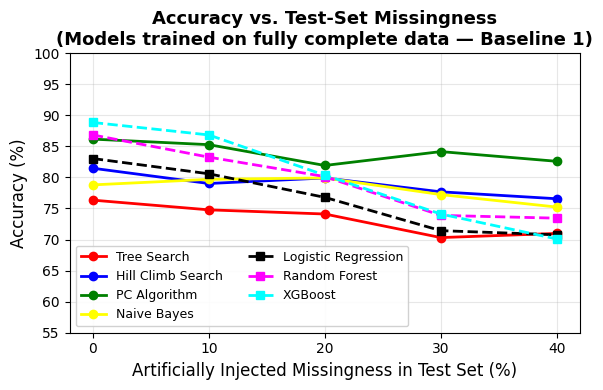

Saved: chart1_missingness_baseline1.png


In [ ]:
plot_missingness_chart(
    'experiment_A_baseline1_results.csv',
    'Accuracy vs. Test-Set Missingness\n(Models trained on fully complete data — Baseline 1)',
    'chart1_missingness_baseline1.png'
)

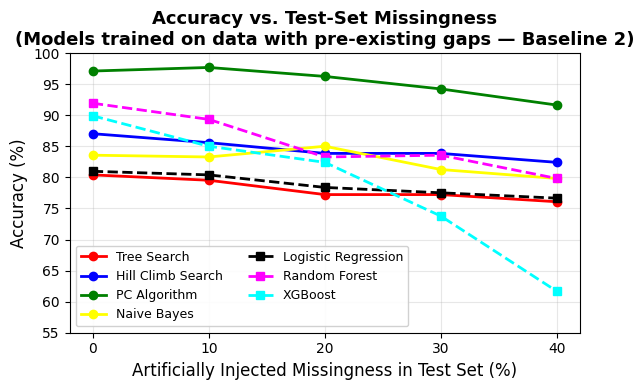

Saved: chart2_missingness_baseline2.png


In [ ]:
plot_missingness_chart(
    'experiment_A_baseline2_results.csv',
    'Accuracy vs. Test-Set Missingness\n(Models trained on data with pre-existing gaps — Baseline 2)',
    'chart2_missingness_baseline2.png'
)

In [ ]:
colors = {
    'Tree Search': 'red',
    'Hill Climb Search': 'blue',
    'PC Algorithm': 'green',
    'Naive Bayes': 'yellow',
    'Logistic Regression': 'black',
    'Random Forest': 'magenta',
    'XGBoost': 'cyan',
}

pgm_models = ['Tree Search', 'Hill Climb Search', 'PC Algorithm', 'Naive Bayes']
ml_models = ['Logistic Regression', 'Random Forest', 'XGBoost']
model_order = pgm_models + ml_models


def plot_f1_chart(csv_path, title, output_path):
    df = pd.read_csv(csv_path)
    fig, ax = plt.subplots(figsize=(9, 6))

    for model in model_order:
        sub = df[df['model'] == model].sort_values('missing_pct')
        linestyle = '-' if model in pgm_models else '--'
        marker = 'o' if model in pgm_models else 's'
        ax.plot(sub['missing_pct'], sub['f1_score'] * 100,
                label=model, color=colors[model], linestyle=linestyle,
                marker=marker, linewidth=2, markersize=6)

    ax.set_xlabel('Artificially Injected Missingness in Test Set (%)', fontsize=12)
    ax.set_ylabel('F1-score (%)', fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xticks([0, 10, 20, 30, 40])
    ax.set_ylim(55, 100)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='lower left', fontsize=9, framealpha=0.9, ncol=2)
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f'Saved: {output_path}')

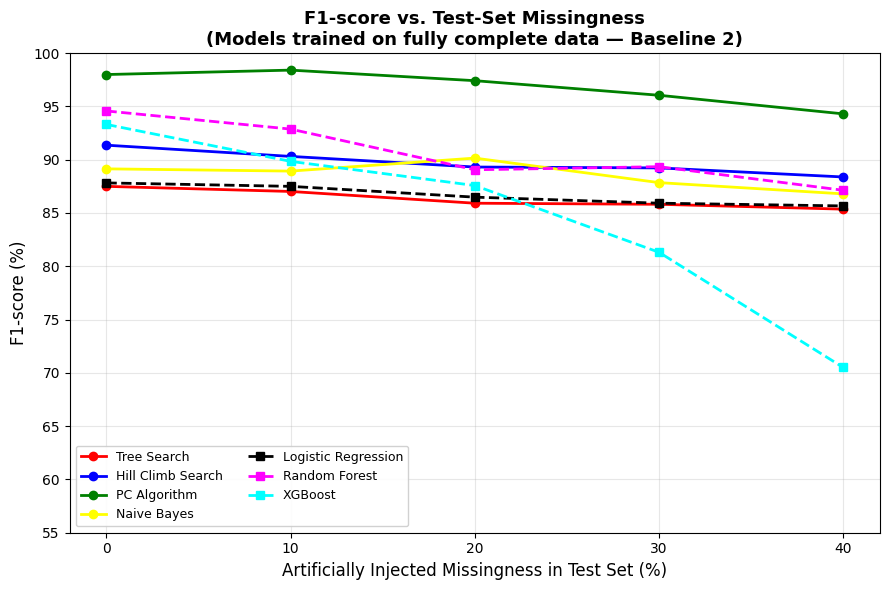

Saved: chart5_f1_missingness_baseline2.png


In [ ]:
plot_f1_chart(
    'experiment_A_baseline2_results.csv',
    'F1-score vs. Test-Set Missingness\n(Models trained on fully complete data — Baseline 2)',
    'chart5_f1_missingness_baseline2.png'
)

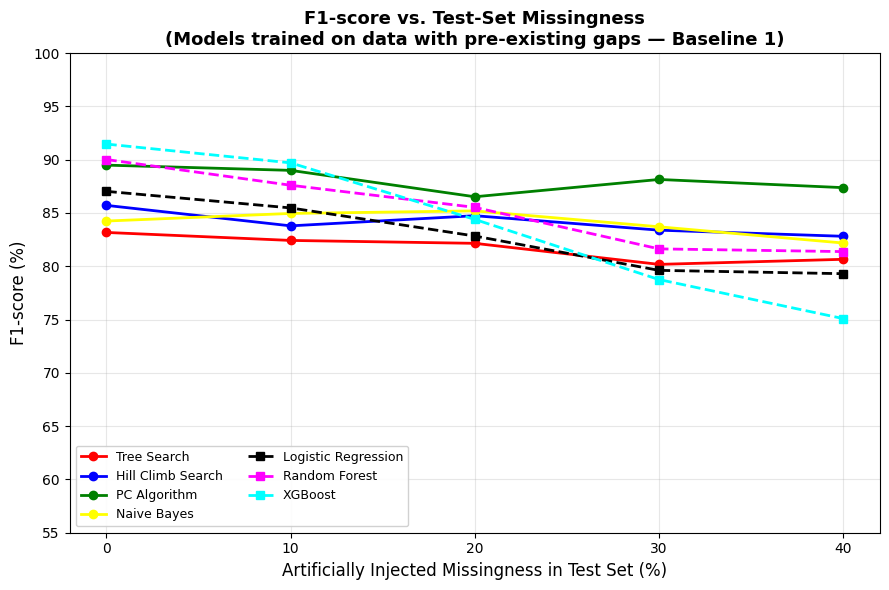

Saved: chart6_f1_missingness_baseline1.png


In [ ]:
plot_f1_chart(
    'experiment_A_baseline1_results.csv',
    'F1-score vs. Test-Set Missingness\n(Models trained on data with pre-existing gaps — Baseline 1)',
    'chart6_f1_missingness_baseline1.png'
)

In [ ]:
import networkx as nx
train_df = pd.read_csv('train_data_complete.csv')
target_col = 'Feeling anxious'
feature_cols = [c for c in train_df.columns if c != target_col]

short_names = {
    'Age': 'Age',
    'Feeling sad or Tearful': 'Sad/\nTearful',
    'Irritable towards baby & partner': 'Irritable',
    'Trouble sleeping at night': 'Sleep\nTrouble',
    'Problems concentrating or making decision': 'Concentration\nProblems',
    'Overeating or loss of appetite': 'Appetite\nChange',
    'Feeling anxious': 'Feeling\nAnxious',
    'Feeling of guilt': 'Guilt',
    'Problems of bonding with baby': 'Bonding\nProblems',
    'Suicide attempt': 'Suicide\nAttempt',
}


def draw_dag(edges, title, output_path, highlight_node='Feeling anxious'):
    G = nx.DiGraph()
    G.add_edges_from(edges)
    for node in short_names:
        if node not in G.nodes():
            G.add_node(node)

    fig, ax = plt.subplots(figsize=(11, 7))
    pos = nx.spring_layout(G, seed=42, k=3.5, iterations=300)

    node_colors = ['red' if n == highlight_node else 'green' for n in G.nodes()]
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=1800, alpha=0.95, ax=ax)
    nx.draw_networkx_edges(G, pos, edge_color='black', arrows=True, arrowsize=14,
                            arrowstyle='-|>', connectionstyle='arc3,rad=0.05',
                            width=1.3, ax=ax, node_size=1800)
    labels = {n: short_names.get(n, n) for n in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=7.5, font_weight='bold', ax=ax)

    ax.set_title(f'{title}\n({len(edges)} edges)', fontsize=13, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f'Saved: {output_path} | {len(edges)} edges')

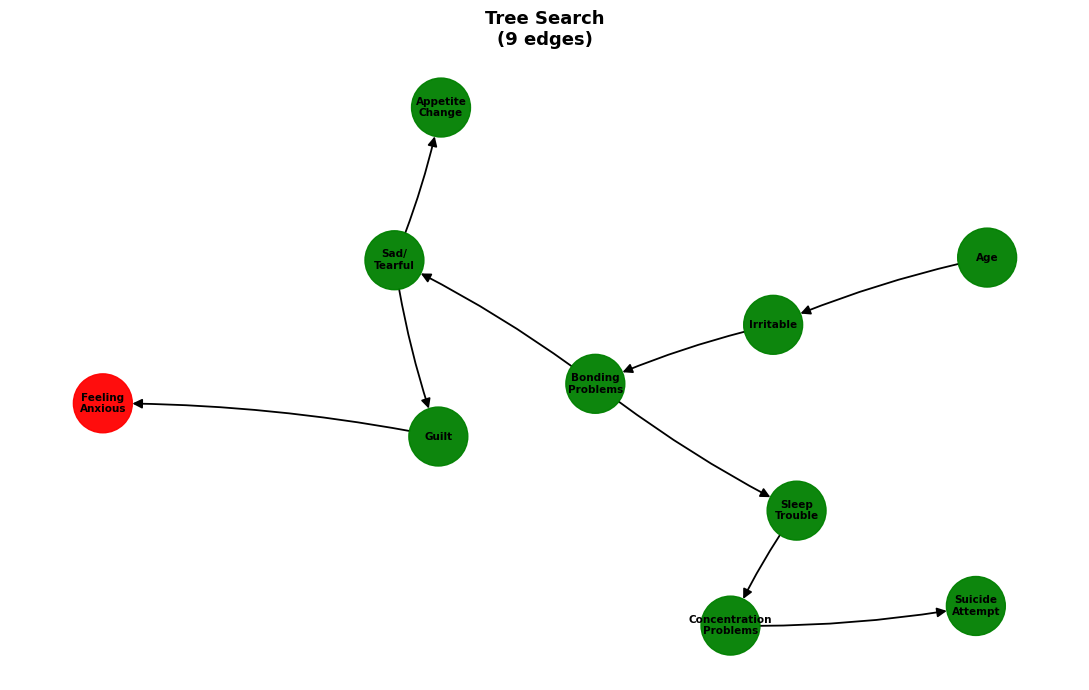

Saved: dag1_tree_search.png | 9 edges


In [ ]:
est = TreeSearch(train_df, root_node='Age')
dag_tree = est.estimate(estimator_type='chow-liu', show_progress=False)
draw_dag(list(dag_tree.edges()), 'Tree Search', 'dag1_tree_search.png')

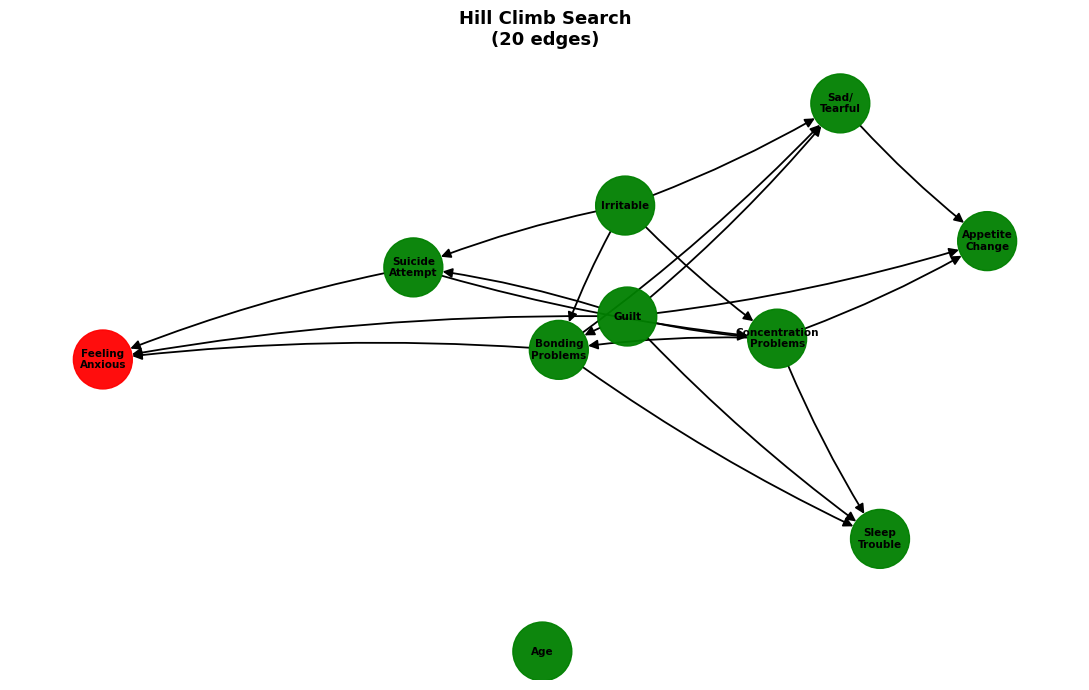

Saved: dag2_hill_climb.png | 20 edges


In [ ]:
scoring = BIC(train_df)
hc = HillClimbSearch(train_df)
dag_hc = hc.estimate(scoring_method=scoring, show_progress=False)
draw_dag(list(dag_hc.edges()), 'Hill Climb Search', 'dag2_hill_climb.png')

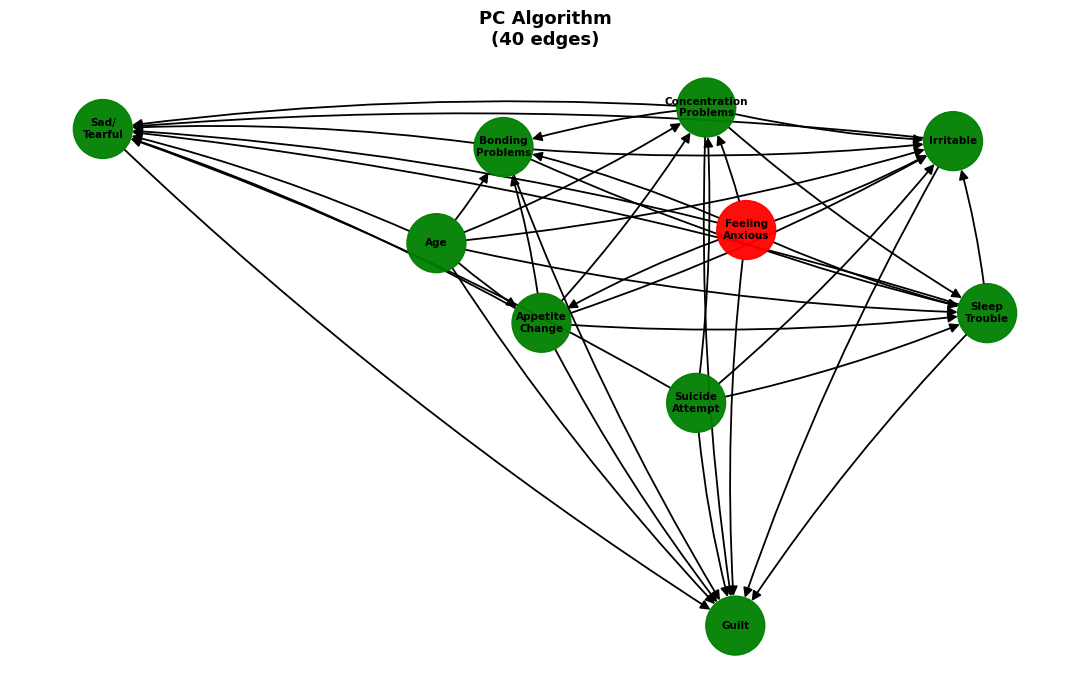

Saved: dag3_pc_algorithm.png | 40 edges


In [ ]:
pc = PC(train_df)
dag_pc = pc.estimate(variant='stable', ci_test='chi_square', return_type='dag',
                      significance_level=0.05, max_cond_vars=3, n_jobs=1, show_progress=False)
draw_dag(list(dag_pc.edges()), 'PC Algorithm', 'dag3_pc_algorithm.png')

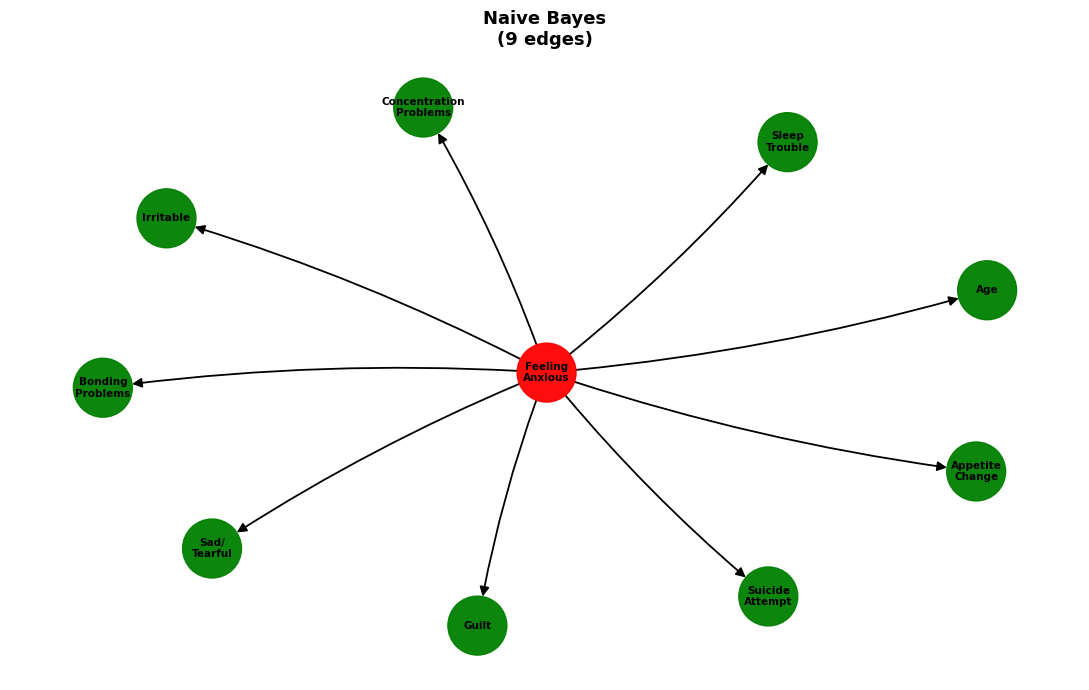

Saved: dag4_naive_bayes.png | 9 edges


In [ ]:
edges_nb = [(target_col, f) for f in feature_cols]
draw_dag(edges_nb, 'Naive Bayes', 'dag4_naive_bayes.png')

In [ ]:
b1 = pd.read_csv('baseline1_results.csv')
b2 = pd.read_csv('complete_baseline_results.csv')

exp_pgm = pd.read_csv('experiment_A_fixed_structure_results.csv')
exp_ml = pd.read_csv('experiment_A_ml_results.csv')
exp_b2 = pd.concat([exp_pgm, exp_ml], ignore_index=True)
exp_at_40 = exp_b2[exp_b2['missing_pct'] == 40][['model', 'accuracy']].rename(columns={'accuracy': 'acc_at_40pct_missing'})

summary = b1[['model', 'accuracy', 'edges']].rename(columns={'accuracy': 'baseline1_acc'})
summary = summary.merge(b2[['model', 'accuracy']].rename(columns={'accuracy': 'baseline2_acc'}), on='model')
summary = summary.merge(exp_at_40, on='model')

summary['accuracy_drop_at_40pct'] = summary['baseline2_acc'] - summary['acc_at_40pct_missing']

model_type = {
    'Tree Search': 'PGM', 'Hill Climb Search': 'PGM', 'PC Algorithm': 'PGM', 'Naive Bayes': 'PGM',
    'Logistic Regression': 'ML', 'Random Forest': 'ML', 'XGBoost': 'ML'
}
summary['type'] = summary['model'].map(model_type)

summary = summary[['model', 'type', 'edges', 'baseline1_acc', 'baseline2_acc',
                    'acc_at_40pct_missing', 'accuracy_drop_at_40pct']]

for col in ['baseline1_acc', 'baseline2_acc', 'acc_at_40pct_missing', 'accuracy_drop_at_40pct']:
    summary[col] = (summary[col] * 100).round(2)

summary = summary.sort_values(['type', 'baseline2_acc'], ascending=[True, False]).reset_index(drop=True)

summary.to_csv('master_summary_table.csv', index=False)
print(summary.to_string(index=False))

              model type  edges  baseline1_acc  baseline2_acc  acc_at_40pct_missing  accuracy_drop_at_40pct
      Random Forest   ML    NaN          86.83          91.93                 79.83                   12.10
            XGBoost   ML    NaN          88.84          89.91                 61.67                   28.24
Logistic Regression   ML    NaN          83.04          80.98                 76.66                    4.32
       PC Algorithm  PGM   39.0          95.88          97.12                 91.64                    5.48
  Hill Climb Search  PGM   20.0          85.29          87.03                 82.42                    4.61
        Naive Bayes  PGM    9.0          80.00          83.57                 79.83                    3.75
        Tree Search  PGM    9.0          77.35          80.40                 76.08                    4.32


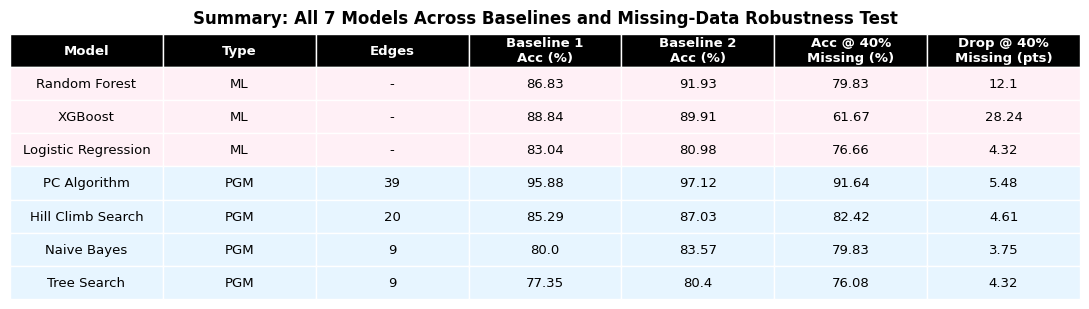

Saved: table1_master_summary.png


In [ ]:
df = pd.read_csv('master_summary_table.csv')
df['edges'] = df['edges'].apply(lambda x: '-' if pd.isna(x) else str(int(x)))

col_labels = ['Model', 'Type', 'Edges', 'Baseline 1\nAcc (%)', 'Baseline 2\nAcc (%)',
              'Acc @ 40%\nMissing (%)', 'Drop @ 40%\nMissing (pts)']

cell_text = df[['model', 'type', 'edges', 'baseline1_acc', 'baseline2_acc',
                'acc_at_40pct_missing', 'accuracy_drop_at_40pct']].values.tolist()

fig, ax = plt.subplots(figsize=(11, 3.2))
ax.axis('off')

table = ax.table(cellText=cell_text, colLabels=col_labels, cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(9.5)
table.scale(1, 2.0)

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('black')
        cell.set_text_props(color='white', fontweight='bold')
    else:
        model_type = df.iloc[row - 1]['type']
        cell.set_facecolor('#e7f5ff' if model_type == 'PGM' else '#fff0f6')
    cell.set_edgecolor('white')

plt.title('Summary: All 7 Models Across Baselines and Missing-Data Robustness Test',
          fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('table1_master_summary.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print('Saved: table1_master_summary.png')

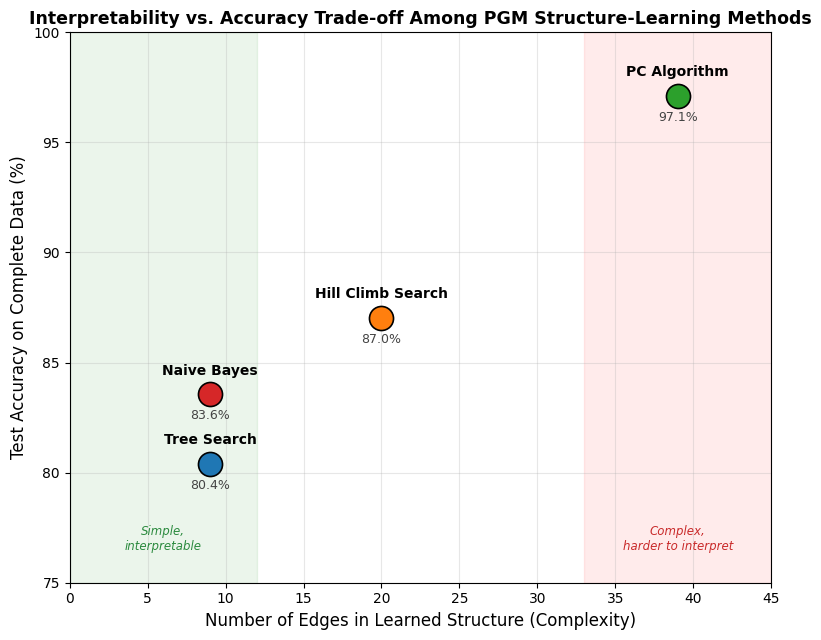

Saved: chart4_edges_vs_accuracy.png


In [ ]:
df = pd.read_csv('master_summary_table.csv')
pgm_df = df[df['type'] == 'PGM'].copy()

fig, ax = plt.subplots(figsize=(8, 6.5))

colors = {'Tree Search': '#1f77b4', 'Hill Climb Search': '#ff7f0e',
          'PC Algorithm': '#2ca02c', 'Naive Bayes': '#d62728'}

for _, row in pgm_df.iterrows():
    ax.scatter(row['edges'], row['baseline2_acc'], s=300,
               color=colors[row['model']], edgecolor='black', linewidth=1.2, zorder=3)
    ax.annotate(row['model'], (row['edges'], row['baseline2_acc']),
                textcoords='offset points', xytext=(0, 14), ha='center', fontsize=10, fontweight='bold')
    ax.annotate(f"{row['baseline2_acc']:.1f}%", (row['edges'], row['baseline2_acc']),
                textcoords='offset points', xytext=(0, -18), ha='center', fontsize=9, color='#444')

ax.set_xlabel('Number of Edges in Learned Structure (Complexity)', fontsize=12)
ax.set_ylabel('Test Accuracy on Complete Data (%)', fontsize=12)
ax.set_title('Interpretability vs. Accuracy Trade-off Among PGM Structure-Learning Methods',
             fontsize=12.5, fontweight='bold')
ax.set_xlim(0, 45)
ax.set_ylim(75, 100)
ax.grid(True, alpha=0.3)

ax.axvspan(0, 12, alpha=0.08, color='green')
ax.text(6, 76.5, 'Simple,\ninterpretable', ha='center', fontsize=8.5, color='#2b8a3e', style='italic')
ax.axvspan(33, 45, alpha=0.08, color='red')
ax.text(39, 76.5, 'Complex,\nharder to interpret', ha='center', fontsize=8.5, color='#c92a2a', style='italic')

plt.tight_layout()
plt.savefig('chart4_edges_vs_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print('Saved: chart4_edges_vs_accuracy.png')